In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("netflix_titles.csv")

print('Dataset loaded')

Dataset loaded


In [28]:
print(df.shape)

(8807, 12)


In [29]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [30]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


### checking data types

In [31]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [32]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### checking for missing values

In [33]:
missing = df.isnull().sum()
missing

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [34]:
missing_percentage = ( missing / len(df)  * 100 ).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percentage
})

missing_df

,Missing Count,Missing %
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
release_year,0,0.00
rating,4,0.05
duration,3,0.03


In [35]:
# showing columns that only have missing values
missing_df[missing_df['Missing Count']>0]

,Missing Count,Missing %
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03


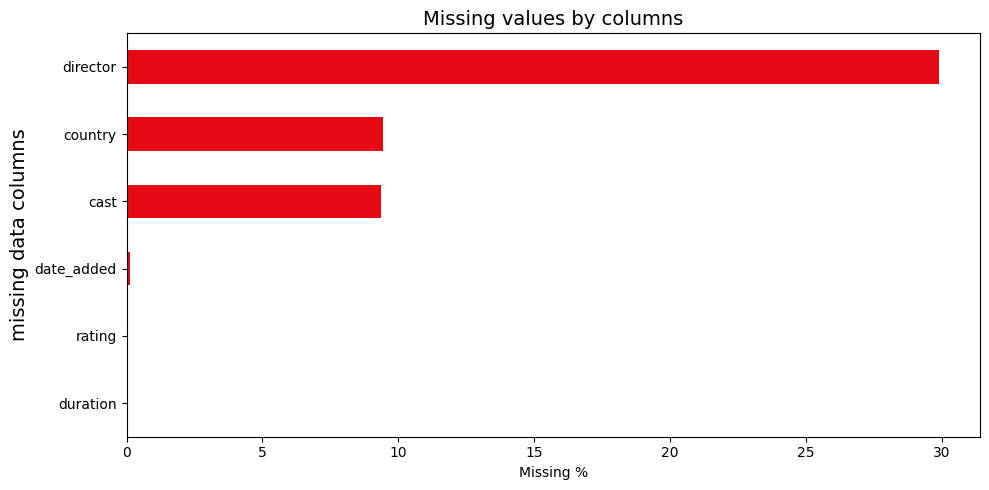

In [36]:
plt.figure(figsize=(10,5))
missing_percentage[missing_percentage>0].sort_values().plot(
    kind = 'barh',
    color = '#E50914'
)
plt.title('Missing values by columns', fontsize = 14)
plt.xlabel('Missing %')
plt.ylabel('missing data columns',fontsize = 14)
plt.tight_layout()
plt.show()

### what i understand upto now ?
data datatype is object but should be datetime

### converting date.dtype object into dateteime and creating column for year and month seperately

In [49]:
# df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

df['date_added'].dtype

dtype('<M8[us]')

In [58]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df[['year_added','month_added']].head()


,year_added,month_added
0,2021.0,9.0
1,2021.0,9.0
2,2021.0,9.0
3,2021.0,9.0
4,2021.0,9.0


### Filling missing text columns with 'Unknown'
### Don't drop them because 30% missing in director is too much to loose

In [60]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added'],
      dtype='str')

In [62]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df.dropna(subset=['rating','duration'], inplace=True) # 3-4 rows missing so safe to remove

### verifying null doesn't exist now

In [64]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
month_added     10
dtype: int64

### here we observed that date was missing date so we should also drop rows having date = null

In [65]:
df.dropna(subset=['date_added','year_added','month_added'], inplace=True)

In [67]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

In [68]:
# Extract just the number from duration
# "90 min" → 90,  "2 Seasons" → 2
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Verify
print(df[['type', 'duration', 'duration_int']].head(10))

      type   duration  duration_int
0    Movie     90 min          90.0
1  TV Show  2 Seasons           2.0
2  TV Show   1 Season           1.0
3  TV Show   1 Season           1.0
4  TV Show  2 Seasons           2.0
5  TV Show   1 Season           1.0
6    Movie     91 min          91.0
7    Movie    125 min         125.0
8  TV Show  9 Seasons           9.0
9    Movie    104 min         104.0
